# Лабораторная работа №1. EDA данных FishGrow
Цель: изучить схему данных, найти проблемы качества, сформулировать
гипотезы о признаках и правило разбиения без утечек.
Модель в этой работе не обучается; тестовая выборка не используется.

## 0. Окружение и загрузка данных

In [1]:
import sys, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

print("Python:", sys.version.split()[0], "|", platform.platform())
for lib in (pd, np, matplotlib, sns):
    print(f"{lib.__name__}: {lib.__version__}")

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

Python: 3.9.13 | Windows-10-10.0.26200-SP0
pandas: 1.3.5
numpy: 1.21.6
matplotlib: 3.8.4
seaborn: 0.13.2


In [2]:
DATA_PATH = Path("../assets/data/Fish.csv")
df = pd.read_csv(DATA_PATH)

assert not df.empty, "Таблица пустая"
assert df.columns.is_unique, "Повторяющиеся имена столбцов"
print("Форма:", df.shape)
df.head()

Форма: (159, 7)


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


## 1. Паспорт данных

In [3]:
# Гипотеза: Height и Width вычислены как процент (с 1 знаком) от Length3
for col in ["Height", "Width"]:
    pct = df[col] / df["Length3"] * 100
    share_round = (pct - pct.round(1)).abs().lt(0.01).mean()
    print(f"{col}: доля строк, где процент от Length3 целый до 0.1 — {share_round:.1%}")

Height: доля строк, где процент от Length3 целый до 0.1 — 100.0%
Width: доля строк, где процент от Length3 целый до 0.1 — 100.0%


**Вывод.** Для 100 % строк (159 из 159) Height и Width равны
«процент с точностью 0,1» × Length3 / 100. Значит, в исходных данных
высота и ширина хранились в процентах от полной длины, а в этой
таблице пересчитаны в единицы длины.

Следствия:
- Height и Width — вычисленные поля; их точность ограничена
  округлением процента, а не точностью измерения;
- их единицы совпадают с единицами Length3;
- Height и Width связаны с Length3 по построению, что усиливает
  мультиколлинеарность признаков.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Weight,159.0,398.326415,357.978317,0.0000,120.00000,273.0000,650.0000,1650.000
Length1,159.0,26.247170,9.996441,7.5000,19.05000,25.2000,32.7000,59.000
Length2,159.0,28.415723,10.716328,8.4000,21.00000,27.3000,35.5000,63.400
Length3,159.0,31.227044,11.610246,8.8000,23.15000,29.4000,39.6500,68.000
Height,159.0,8.970994,4.286208,1.7284,5.94480,7.7860,12.3659,18.957
Width,159.0,4.417486,1.685804,1.0476,3.38565,4.2485,5.5845,8.142


In [6]:
df["Species"].value_counts()

Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: Species, dtype: int64

In [7]:
df["Species"].map(repr).unique()

array(["'Bream'", "'Roach'", "'Whitefish'", "'Parkki'", "'Perch'",
       "'Pike'", "'Smelt'"], dtype=object)

**Наблюдения.**
- 159 строк × 7 столбцов, пропусков нет, типы корректны.
- Species: 7 категорий без скрытых пробелов и вариантов написания;
  сильный дисбаланс — от 56 (Perch, 35 %) до 6 (Whitefish, 3,8 %).
- Weight: минимум 0 г — физически невозможное значение (аномалия).
- Weight скошена вправо: среднее 398 г > медиана 273 г.
- Единицы: длины 8,8–68 — правдоподобны только в сантиметрах
  (в мм — слишком малы для массы до 1,6 кг, в дм — слишком велики);
  масса 0–1650 — правдоподобна в граммах.

In [8]:
df[df["Weight"] == 0]

,Species,Weight,Length1,Length2,Length3,Height,Width
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516


In [9]:
roach = df[df["Species"] == "Roach"]
roach[(roach["Length3"] - 22.8).abs() <= 2].sort_values("Length3")

,Species,Weight,Length1,Length2,Length3,Height,Width
37,Roach,78.0,17.5,18.8,21.2,5.5756,2.9044
38,Roach,87.0,18.2,19.8,22.2,5.6166,3.1746
39,Roach,120.0,18.6,20.0,22.2,6.2160,3.5742
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516
41,Roach,110.0,19.1,20.8,23.1,6.1677,3.3957
42,Roach,120.0,19.4,21.0,23.7,6.1146,3.2943
44,Roach,145.0,20.5,22.0,24.3,6.6339,3.5478
43,Roach,150.0,20.4,22.0,24.7,5.8045,3.7544


**Аномалия: строка 40 (Roach), Weight = 0 г.** Длины (19,0 / 20,5 / 22,8)
и пропорции тела правдоподобны и согласуются с другими особями плотвы;
рыбы того же вида близкой длины весят около 78–150 г. Масса 0 физически
невозможна — вероятна ошибка ввода или пропуск, записанный нулём.
Исправить по источнику нельзя (первичных записей нет).
**Решение:** исключить строку из обучения и оценки модели как целевое
значение-ошибку; в исходных данных не изменять.

### Паспорт данных

Единица наблюдения: одна рыба (предположение — идентификатора нет).
Размер: 159 строк × 7 столбцов. Пропусков нет.

| Поле | Смысл | Тип | Единицы | Роль | Пропуски | Диапазон / словарь | Источник | Что проверить |
|---|---|---|---|---|---|---|---|---|
| Species | вид рыбы | категориальный | словарь | признак; группа для стратификации | нет | 7 видов: Perch 56, Bream 35, Roach 20, Pike 17, Smelt 14, Parkki 11, Whitefish 6 | запись при улове | редкие виды, новые виды при эксплуатации |
| Weight | масса рыбы | числовой (float64; в README автора — int) | г (README автора; согласуется с диапазоном) | целевая | нет | 0–1650; > 0; 0 в строке 40 — аномалия | Kaggle Fish Market (Aung Pyae), по README автора | нули |
| Length1 | длина; в README — «Vertical length», трактовка неоднозначна | числовой (float64) | см (README) | признак | нет | 7,5–59,0 | README автора | L1 ≤ L2 |
| Length2 | длина; в README — «Diagonal length» | числовой | см (README) | признак | нет | 8,4–63,4 | README автора | L1 ≤ L2 ≤ L3 |
| Length3 | длина; в README — «Cross length» | числовой | см (README) | признак | нет | 8,8–68,0 | README автора | согласованность |
| Height | высота; в README — «Height» | числовой | см (README) | признак | нет | 1,73–18,96 | вычисление: % × Length3 / 100 (проверено; в README не указано) | зависимость от Length3 |
| Width | ширина; в README — «Diagonal width» | числовой | см (README) | признак | нет | 1,05–8,14 | вычисление: % × Length3 / 100 (проверено; в README не указано) | зависимость от Length3 |

**Единица независимого наблюдения.** Предполагается, что одна строка —
одна рыба. В данных нет идентификатора рыбы, партии, водоёма или даты,
поэтому проверить, относятся ли строки к одному объекту, партии или
моменту времени, невозможно. Строки упорядочены по видам, что отражает
порядок записи, но не структуру партий. Повторные измерения одной рыбы
косвенно проверяются поиском дубликатов и почти одинаковых строк
(раздел 2). Групповое разбиение невозможно из-за отсутствия группирующего
признака; независимость строк — допущение (см. «Риски»).

## 2. Проверки качества

In [10]:
import sys
sys.path.insert(0, str(Path("..").resolve()))

from src import data_checks as dc

In [11]:
schema_problems = dc.check_schema(df)
print(schema_problems or "Схема совпадает с ожидаемой")

Схема совпадает с ожидаемой


In [12]:
summary = dc.run_row_checks(df)
summary

,check,n_rows,rows
0,полные дубликаты,0,[]
1,пропуски / бесконечности,0,[]
2,значения <= 0,1,[40]
3,порядок длин,0,[]
4,пропорции тела,0,[]


In [13]:
pd.concat([dc.check_non_positive(df),
           dc.check_length_order(df),
           dc.check_proportions(df)])

,Species,Weight,Length1,Length2,Length3,Height,Width,issue
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516,Weight <= 0


In [14]:
dc.check_rare_categories(df)

,count,share,rare
Perch,56,0.352201,False
Bream,35,0.220126,False
Roach,20,0.125786,False
Pike,17,0.106918,False
Smelt,14,0.088050,False
Parkki,11,0.069182,False
Whitefish,6,0.037736,True


In [15]:
near = dc.check_near_duplicates(df, threshold=0.05)
print(f"Пар почти-дубликатов: {len(near)}")
near

Пар почти-дубликатов: 4


,row_a,row_b,Species,distance
0,25,26,Bream,0.0417
1,103,104,Perch,0.0304
2,149,150,Smelt,0.0334
3,152,153,Smelt,0.0252


In [16]:
dc.check_unique_columns(df)

,nunique,unique_ratio,id_candidate
Species,7,0.044025,False
Weight,101,0.635220,False
Length1,116,0.729560,False
Length2,93,0.584906,False
Length3,124,0.779874,False
Height,154,0.968553,False
Width,152,0.955975,False


In [17]:
for a, b in near[["row_a", "row_b"]].itertuples(index=False):
    display(df.loc[[a, b]])

,Species,Weight,Length1,Length2,Length3,Height,Width
25,Bream,725.0,31.8,35.0,40.9,16.3600,6.0532
26,Bream,720.0,32.0,35.0,40.6,16.3618,6.0900


,Species,Weight,Length1,Length2,Length3,Height,Width
103,Perch,260.0,25.4,27.5,28.9,7.1672,4.335
104,Perch,265.0,25.4,27.5,28.9,7.0516,4.335


,Species,Weight,Length1,Length2,Length3,Height,Width
149,Smelt,9.8,10.7,11.2,12.4,2.0832,1.2772
150,Smelt,8.7,10.8,11.3,12.6,1.9782,1.2852


,Species,Weight,Length1,Length2,Length3,Height,Width
152,Smelt,9.9,11.3,11.8,13.1,2.2139,1.1659
153,Smelt,9.8,11.4,12.0,13.2,2.2044,1.1484


**Результаты проверок качества.**
- Схема совпадает с ожидаемой; пропусков, бесконечностей и полных
  дубликатов нет.
- Значения ≤ 0: одна строка — 40 (Roach, Weight = 0), см. раздел 1.
- Порядок Length1 ≤ Length2 ≤ Length3 выполняется во всех 159 строках —
  косвенное подтверждение того, что длины измерены до всё более дальних
  точек тела.
- Пропорции тела корректны: Height и Width меньше Length3 во всех строках.
- Редкая категория: Whitefish (6 строк, 3,8 %).
- Кандидатов в идентификаторы нет. Высокая уникальность Height и Width
  (≈ 97 %) объясняется их вычисленным характером (4 знака после запятой),
  а не ролью идентификатора.
- Почти-дубликаты (порог 0,05 ст. откл.): 4 пары соседних строк —
  25/26 (Bream), 103/104 (Perch), 149/150 и 152/153 (Smelt).
  Во всех парах различаются масса и хотя бы часть размеров, поэтому
  это не копии записи. Соседство объясняется порядком записи
  (внутри вида по размеру). Наиболее подозрительна пара 103/104:
  три длины и ширина совпадают, но масса (260 / 265 г) и высота
  различаются — вероятно, две рыбы одного размера.

  **Решение:** строки оставить; пару 103/104 при разбиении держать
  в одной части выборки как возможное повторное измерение.

## 3. Визуализация

In [18]:
# ===== Ячейка 3.0 — настройки графиков =====
SPECIES_ORDER = ["Perch", "Bream", "Roach", "Pike", "Smelt", "Parkki", "Whitefish"]  # по численности
PALETTE = dict(zip(SPECIES_ORDER,
                   ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
MARKERS = dict(zip(SPECIES_ORDER, ["o", "s", "^", "D", "v", "P", "X"]))  # форма дублирует цвет
 
UNITS = {"Weight": "масса, г", "Length1": "Length1, см", "Length2": "Length2, см",
         "Length3": "Length3, см", "Height": "высота, см", "Width": "ширина, см"}
 
sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
 
def save(fig, name):
    """Сохраняет рисунок в reports/figures/ для отчёта."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

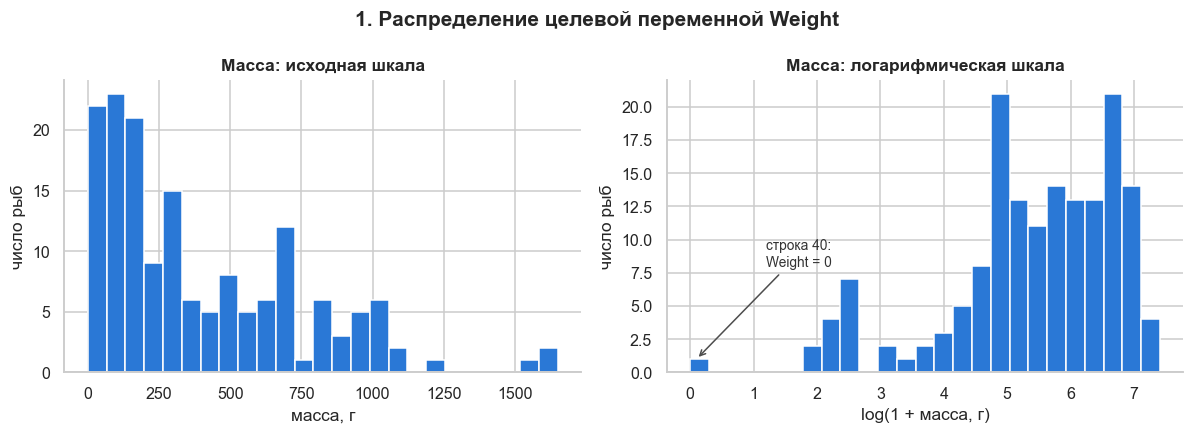

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["Weight"], bins=25, color="#2a78d6", edgecolor="white")
axes[0].set(title="Масса: исходная шкала", xlabel="масса, г", ylabel="число рыб")
axes[1].hist(np.log1p(df["Weight"]), bins=25, color="#2a78d6", edgecolor="white")
axes[1].set(title="Масса: логарифмическая шкала", xlabel="log(1 + масса, г)", ylabel="число рыб")
axes[1].annotate("строка 40:\nWeight = 0", xy=(0.1, 1), xytext=(1.2, 8),
                 arrowprops=dict(arrowstyle="->", color="0.3"), fontsize=9, color="0.2")
fig.suptitle("1. Распределение целевой переменной Weight", fontweight="bold")
fig.tight_layout(); save(fig, "01_weight_distribution"); plt.show()

**Вывод.** В исходной шкале масса сильно скошена вправо: основная часть рыб
легче 500 г (медиана 273 г, среднее 398 г), несколько крупных особей
(до 1650 г) образуют длинный правый хвост. После логарифмирования
распределение становится ближе к симметричному. Отдельно у нуля
находится строка 40 (Weight = 0) — невозможное значение.
Следствие: при моделировании целесообразно предсказывать log(масса),
тогда ошибки становятся относительными и мелкие рыбы не теряются
на фоне крупных.

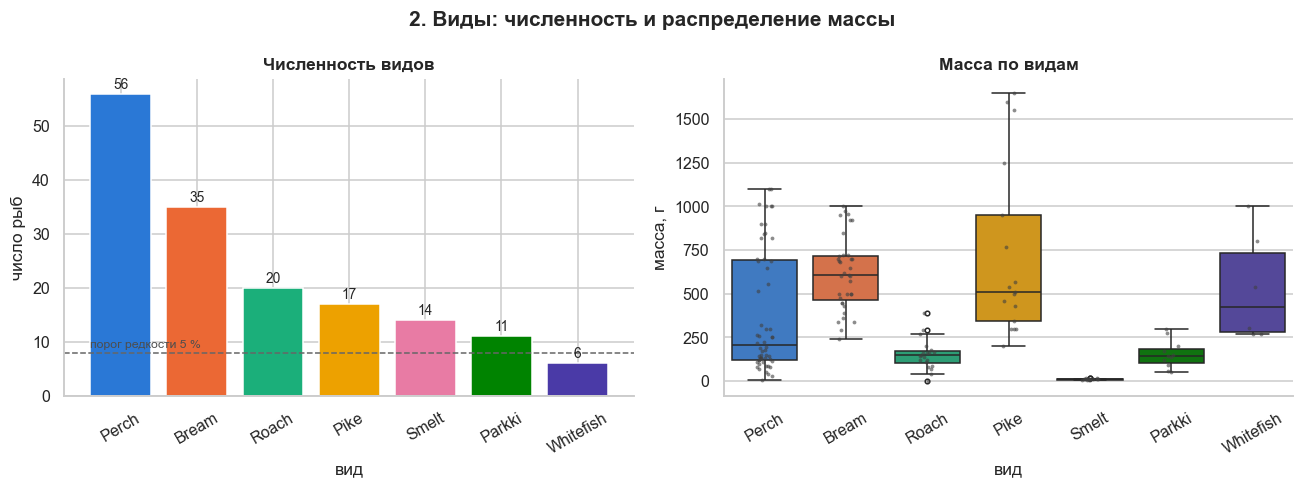

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
counts = df["Species"].value_counts().reindex(SPECIES_ORDER)
axes[0].bar(counts.index, counts.values, color=[PALETTE[s] for s in counts.index])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontsize=9)
axes[0].axhline(len(df) * 0.05, ls="--", color="0.4", lw=1)
axes[0].text(-0.4, len(df) * 0.05 + 1, "порог редкости 5 %", ha="left", fontsize=8, color="0.3")
axes[0].set(title="Численность видов", xlabel="вид", ylabel="число рыб")
 
sns.boxplot(data=df, x="Species", y="Weight", order=SPECIES_ORDER, hue="Species",
            palette=PALETTE, legend=False, ax=axes[1], fliersize=3)
sns.stripplot(data=df, x="Species", y="Weight", order=SPECIES_ORDER,
              color="0.25", size=2.5, alpha=0.6, ax=axes[1])
axes[1].set(title="Масса по видам", xlabel="вид", ylabel="масса, г")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("2. Виды: численность и распределение массы", fontweight="bold")
fig.tight_layout(); save(fig, "02_species"); plt.show()

**Вывод.** Виды сильно несбалансированы: от 56 особей (Perch, 35 %) до 6
(Whitefish, 3,8 %); Whitefish — ниже порога редкости 5 %, при разбиении
в тестовую выборку попадёт 1 особь. Масса сильно зависит от вида:
Smelt — до ~20 г, Pike — до 1650 г; наибольший разброс массы у Pike
и Perch, наименьший — у Smelt и Parkki. Строка 40 видна как нижний
выброс у Roach. Следствия: вид — важный признак; выбросы нужно искать
внутри вида; разбиение — стратифицированное по виду.

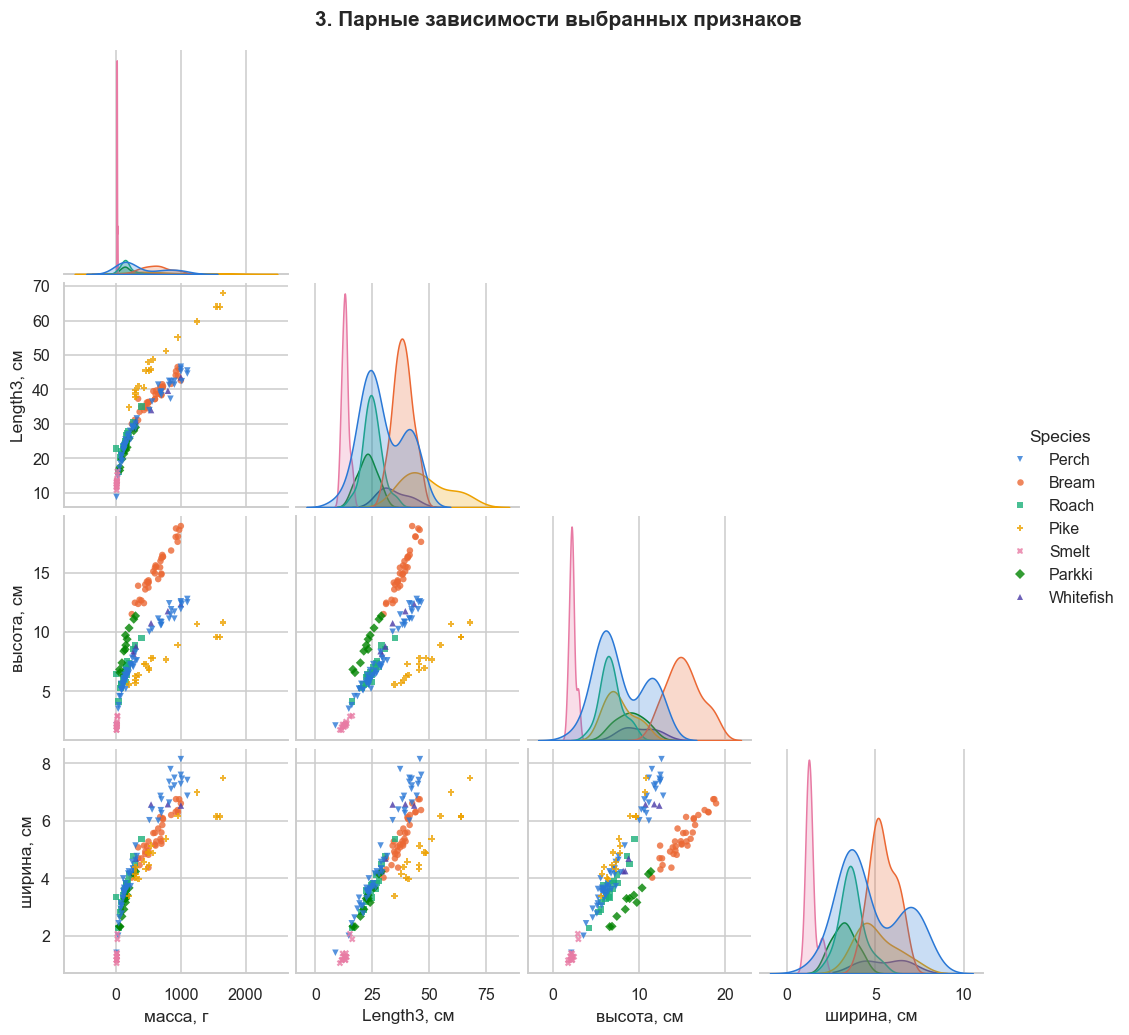

In [21]:
pair_cols = ["Weight", "Length3", "Height", "Width"]
g = sns.pairplot(df[pair_cols + ["Species"]].rename(columns=UNITS),
                 hue="Species", hue_order=SPECIES_ORDER, palette=PALETTE,
                 markers=[MARKERS[s] for s in SPECIES_ORDER],
                 plot_kws=dict(s=18, alpha=0.8, linewidth=0), height=2.3, corner=True)
g.figure.suptitle("3. Парные зависимости выбранных признаков", fontweight="bold", y=1.02)
save(g.figure, "03_pairplot"); plt.show()

**Вывод.** Связь массы с длиной, высотой и шириной нелинейная (масса
растёт быстрее размеров) и различается по видам: при одинаковой длине
Pike заметно легче Bream и Perch. На графике «высота — длина» виды
образуют отдельные лучи с разным наклоном: пропорции тела видоспецифичны
(Bream — высокий, Pike и Smelt — вытянутые). Внутри вида размеры связаны
почти линейно — признак коллинеарности. Length1 и Length2 не показаны:
они практически дублируют Length3.

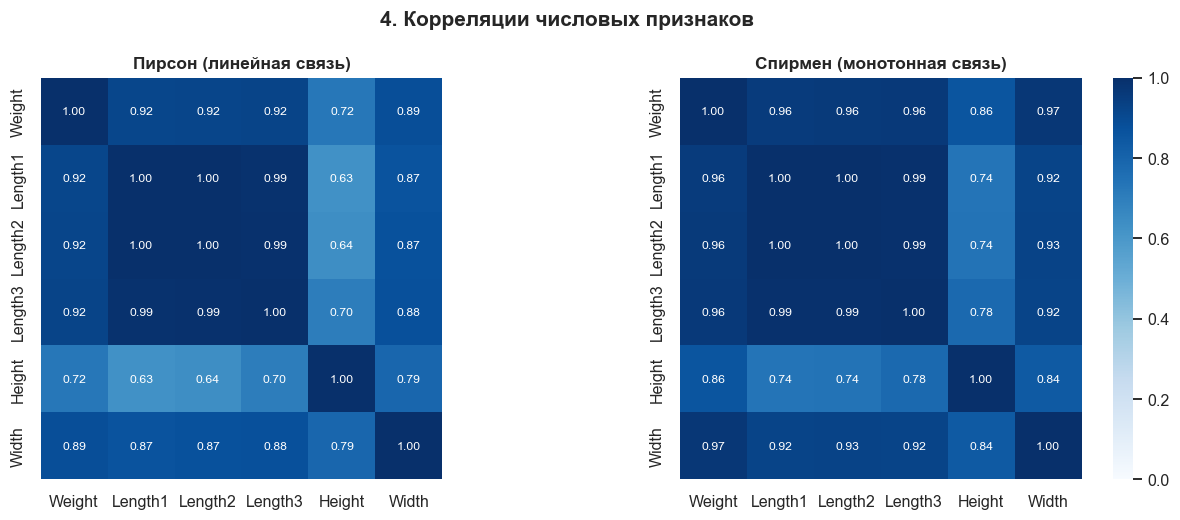

In [22]:
num_cols = ["Weight", "Length1", "Length2", "Length3", "Height", "Width"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, method, title in zip(axes, ["pearson", "spearman"],
                             ["Пирсон (линейная связь)", "Спирмен (монотонная связь)"]):
    corr = df[num_cols].corr(method=method)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                square=True, cbar=ax is axes[1], ax=ax, annot_kws={"size": 8})
    ax.set_title(title)
fig.suptitle("4. Корреляции числовых признаков", fontweight="bold")
fig.tight_layout(); save(fig, "04_correlations"); plt.show()

**Вывод.** Все размеры сильно связаны с массой (Пирсон: Length3 —
[≈ 0,92], Width — [≈ 0,89], Height — [≈ 0,72]). Коэффициенты Спирмена
выше, чем Пирсона: зависимость монотонная, но нелинейная, и Пирсон её
недооценивает. Length1, Length2 и Length3 коррелируют практически
полностью (≈ 0,99) — мультиколлинеарность. Height связана с остальными
признаками слабее, так как отражает форму тела, зависящую от вида.
Оговорка: корреляция по всей таблице смешивает виды и не доказывает
причинной связи.

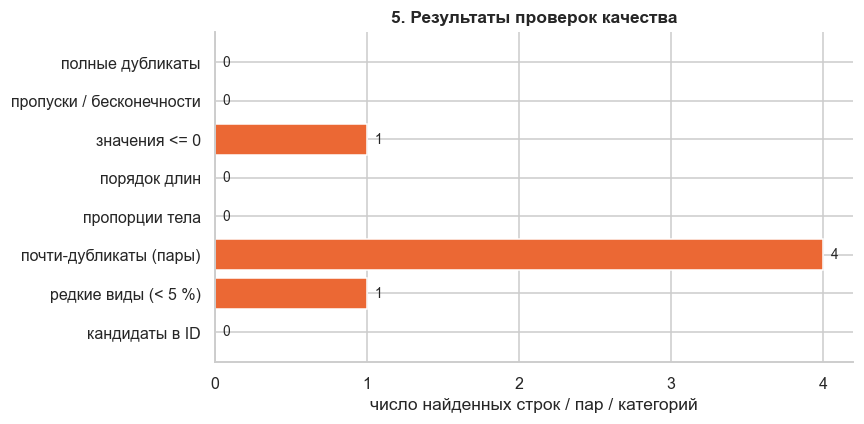

In [23]:
quality = dc.run_row_checks(df)[["check", "n_rows"]].copy()
extra = pd.DataFrame({
    "check": ["почти-дубликаты (пары)", "редкие виды (< 5 %)", "кандидаты в ID"],
    "n_rows": [len(dc.check_near_duplicates(df)),
               int(dc.check_rare_categories(df)["rare"].sum()),
               int(dc.check_unique_columns(df)["id_candidate"].sum())],
})
quality = pd.concat([quality, extra], ignore_index=True)
 
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#eb6834" if n > 0 else "#b8b8b0" for n in quality["n_rows"]]
ax.barh(quality["check"], quality["n_rows"], color=colors)
for y, n in enumerate(quality["n_rows"]):
    ax.text(n + 0.05, y, str(n), va="center", fontsize=9)
ax.invert_yaxis()
ax.set(title="5. Результаты проверок качества", xlabel="число найденных строк / пар / категорий",
       ylabel="")
ax.xaxis.get_major_locator().set_params(integer=True)
fig.tight_layout(); save(fig, "05_quality"); plt.show()

**Вывод.** Данные в целом чистые: пропусков, бесконечностей, полных
дубликатов, нарушений порядка Length1 ≤ Length2 ≤ Length3 и невозможных
пропорций тела нет. Найдены: одно невозможное значение (строка 40,
Weight = 0), четыре пары почти одинаковых строк (разобраны в разделе 2 —
разные рыбы, пара 103/104 держится в одной части разбиения) и одна
редкая категория (Whitefish). Кандидатов в идентификаторы нет.

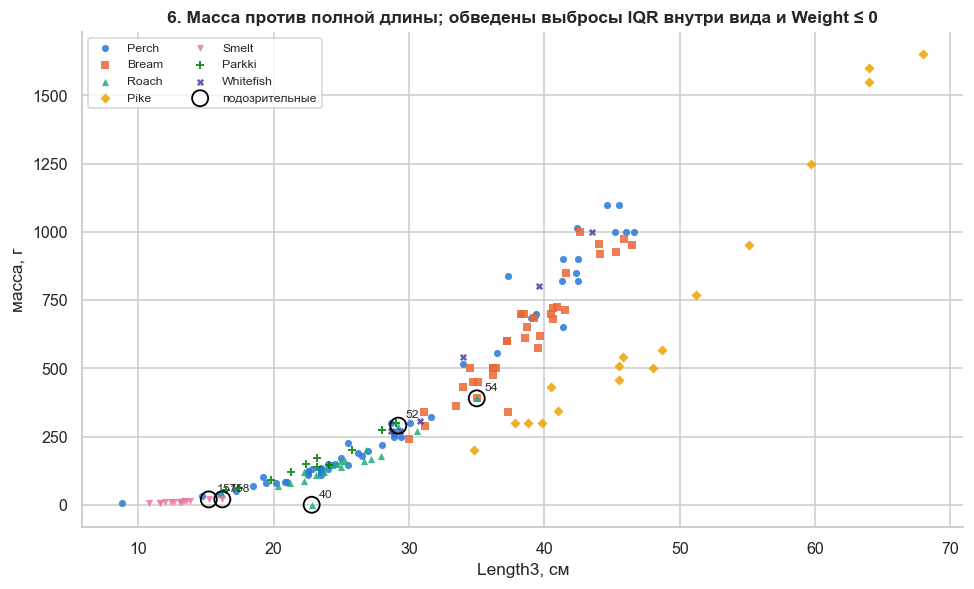

Помеченные строки: [40, 52, 54, 157, 158]


In [24]:
def iqr_mask(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    return (s < q1 - k * (q3 - q1)) | (s > q3 + k * (q3 - q1))
 
flag = df.groupby("Species")["Weight"].transform(iqr_mask).astype(bool) | (df["Weight"] <= 0)
 
fig, ax = plt.subplots(figsize=(9, 5.5))
for s in SPECIES_ORDER:
    part = df[df["Species"] == s]
    ax.scatter(part["Length3"], part["Weight"], s=22, color=PALETTE[s],
               marker=MARKERS[s], label=s, alpha=0.85, linewidths=0)
ax.scatter(df.loc[flag, "Length3"], df.loc[flag, "Weight"], s=110,
           facecolors="none", edgecolors="black", linewidths=1.2, label="подозрительные")
for i, r in df[flag].iterrows():
    ax.annotate(str(i), (r["Length3"], r["Weight"]), xytext=(5, 5),
                textcoords="offset points", fontsize=8)
ax.set(title="6. Масса против полной длины; обведены выбросы IQR внутри вида и Weight ≤ 0",
       xlabel="Length3, см", ylabel="масса, г")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); save(fig, "06_outliers"); plt.show()
print("Помеченные строки:", sorted(df.index[flag].tolist()))

**Вывод.** По правилу IQR внутри вида и условию Weight ≤ 0 помечены строки
40, 52, 54, 157, 158. Строки 52 и 54 (крупнейшая плотва), 157 и 158
(крупнейшая корюшка) лежат на общей кривой масса–длина: это крупные
особи с нормальными пропорциями — выбросы по массе, но не ошибки.
Строка 40 (длина 22,8 см, масса 0) выпадает из зависимости — ошибка
ввода. Pike образует отдельную ветвь ниже общего облака — особенность
вида (вытянутое тело), а не выброс. Одномерный IQR по массе не учитывает
размер рыбы, поэтому в разделе 4 дополнительно оценивается отклонение
массы от ожидаемой при данной длине.

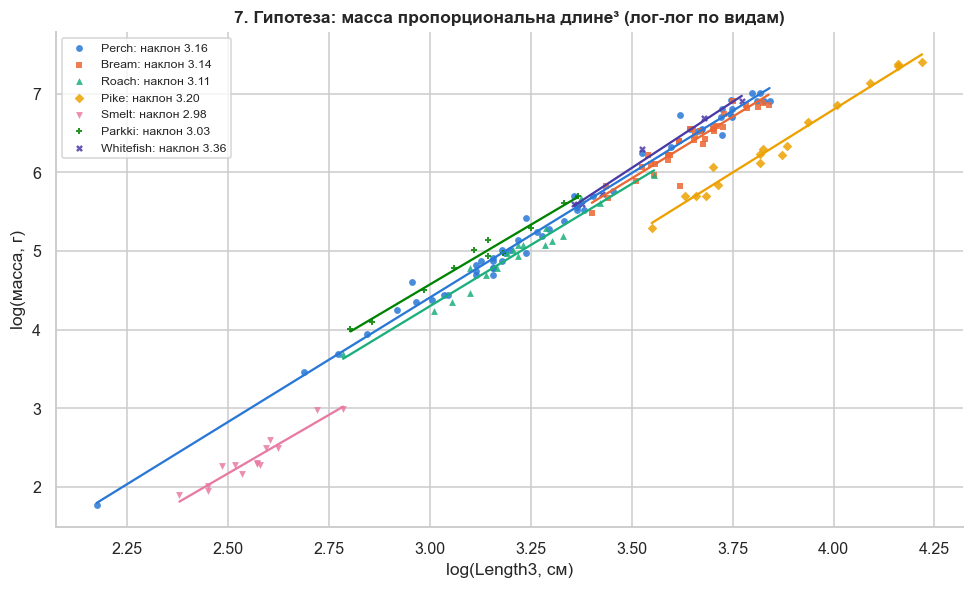

Perch        3.16
Bream        3.14
Roach        3.11
Pike         3.20
Smelt        2.98
Parkki       3.03
Whitefish    3.36
Name: наклон b, dtype: float64

In [25]:
pos = df[df["Weight"] > 0]          # log(0) не определён — строка 40 исключена
fig, ax = plt.subplots(figsize=(9, 5.5))
slopes = {}
for s in SPECIES_ORDER:
    part = pos[pos["Species"] == s]
    x, y = np.log(part["Length3"]), np.log(part["Weight"])
    b, a = np.polyfit(x, y, 1)
    slopes[s] = b
    ax.scatter(x, y, s=20, color=PALETTE[s], marker=MARKERS[s], alpha=0.85, linewidths=0,
               label=f"{s}: наклон {b:.2f}")
    xs = np.linspace(x.min(), x.max(), 10)
    ax.plot(xs, a + b * xs, color=PALETTE[s], lw=1.5)
ax.set(title="7. Гипотеза: масса пропорциональна длине³ (лог-лог по видам)",
       xlabel="log(Length3, см)", ylabel="log(масса, г)")
ax.legend(fontsize=8)
fig.tight_layout(); save(fig, "07_loglog_hypothesis"); plt.show()
pd.Series(slopes, name="наклон b").round(2)

**Вывод.** В лог-лог координатах зависимость массы от длины близка
к линейной для всех видов. Наклоны лежат в диапазоне 2.98-3.36, т. е.
близко к 3, что подтверждает гипотезу «масса пропорциональна длине³»
(при росте рыба в основном сохраняет форму). Прямые разных видов смещены
по вертикали: при равной длине виды различаются массой из-за формы тела.
Оценки для Whitefish (6 рыб) и Parkki (11) ненадёжны из-за малого числа
наблюдений. Строка 40 исключена (логарифм нуля не определён).
Следствие для модели: использовать log(масса), log(длины) и вид.

## 4. Выбросы: IQR и MAD

IQR и MAD считаются внутри каждого вида: масса и размеры сильно зависят
от вида, и крупная щука не должна считаться выбросом на фоне корюшки.
Границы в этом разделе оценены по всей таблице — это допустимо для
описательного анализа; при моделировании их нужно оценивать только
на обучающей выборке (иначе утечка, см. раздел 6).

In [26]:
# ===== Ячейка 4.1 — пропуски =====
missing = df.isna().sum()
print("Пропусков по столбцам:\n", missing.to_string())
print("\nСкрытые пропуски (нули в физических величинах):")
display(dc.check_non_positive(df))

Пропусков по столбцам:
 Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0

Скрытые пропуски (нули в физических величинах):


,Species,Weight,Length1,Length2,Length3,Height,Width,issue
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516,Weight <= 0


In [27]:
# ===== Ячейка 4.2 — IQR и MAD для массы внутри вида =====
out_w = dc.outlier_table(df, "Weight")
out_w

,Species,Weight,iqr_flag,mad_z,mad_flag,agreement
40,Roach,0.0,True,-2.84,False,только IQR
52,Roach,290.0,True,2.75,False,только IQR
54,Roach,390.0,True,4.67,True,оба метода
111,Perch,840.0,False,3.63,True,только MAD
116,Perch,900.0,False,3.98,True,только MAD
118,Perch,820.0,False,3.52,True,только MAD
119,Perch,850.0,False,3.69,True,только MAD
120,Perch,900.0,False,3.98,True,только MAD
121,Perch,1015.0,False,4.64,True,только MAD
122,Perch,820.0,False,3.52,True,только MAD


In [28]:
# ===== Ячейка 4.3 — границы IQR и медиана/MAD по видам (для отчёта) =====
bounds = df.groupby("Species")["Weight"].apply(dc.iqr_bounds).unstack().round(1)
mads = df.groupby("Species")["Weight"].agg(
    median="median",
    MAD=lambda s: (s - s.median()).abs().median()).round(1)
bounds.join(mads).reindex(SPECIES_ORDER)

,q1,q3,iqr,low,high,median,MAD
Species,,,,,,,
Perch,120.0,692.5,572.5,-738.8,1551.2,207.5,117.5
Bream,462.5,717.0,254.5,80.8,1098.8,610.0,115.0
Roach,104.2,171.8,67.5,3.0,273.0,147.5,35.0
Pike,345.0,950.0,605.0,-562.5,1857.5,510.0,210.0
Smelt,9.0,12.2,3.2,4.1,17.1,9.9,2.3
Parkki,105.0,185.0,80.0,-15.0,305.0,145.0,55.0
Whitefish,279.0,735.0,456.0,-405.0,1419.0,423.0,153.0


In [29]:
# ===== Ячейка 4.4 — IQR и MAD по всем числовым признакам (сводка) =====
rows = []
for col in dc.NUMERIC_COLUMNS:
    t = dc.outlier_table(df, col)
    rows.append({"признак": col,
                 "IQR": int(t["iqr_flag"].sum()),
                 "MAD": int(t["mad_flag"].sum()),
                 "оба": int((t["iqr_flag"] & t["mad_flag"]).sum()),
                 "строки": sorted(t.index.tolist())})
pd.DataFrame(rows)

,признак,IQR,MAD,оба,строки
0,Weight,5,14,1,"[40, 52, 54, 111, 116, 118, 119, 120, 121, 122..."
1,Length1,4,1,1,"[34, 35, 54, 158]"
2,Length2,4,1,1,"[35, 54, 157, 158]"
3,Length3,3,0,0,"[35, 54, 158]"
4,Height,5,0,0,"[35, 52, 54, 157, 158]"
5,Width,5,3,3,"[35, 53, 54, 157, 158]"


In [30]:
# ===== Ячейка 4.5 — отклонение массы от ожидаемой при данной длине =====
# Модель «масса = k · длина^b» для каждого вида (прямая в лог-лог координатах).
# Строка 40 (Weight = 0) не участвует в подгонке: логарифм нуля не определён.
pos = df[df["Weight"] > 0]
fit = {}
for s, part in pos.groupby("Species"):
    b, a = np.polyfit(np.log(part["Length3"]), np.log(part["Weight"]), 1)
    fit[s] = (a, b)

a_ = df["Species"].map(lambda s: fit[s][0])
b_ = df["Species"].map(lambda s: fit[s][1])
df_resid = df[["Species", "Length3", "Weight"]].copy()
df_resid["expected_weight"] = np.exp(a_ + b_ * np.log(df["Length3"])).round(1)
df_resid["ratio"] = (df["Weight"] / df_resid["expected_weight"]).round(2)  # факт / ожидание

ok = df["Weight"] > 0
df_resid["resid_log"] = np.nan
df_resid.loc[ok, "resid_log"] = np.log(df.loc[ok, "Weight"]) - np.log(df_resid.loc[ok, "expected_weight"])
df_resid["resid_mad_z"] = dc.mad_z(df_resid.dropna(subset=["resid_log"]), "resid_log").round(2)
flag_resid = (df_resid["resid_mad_z"].abs() > 3.5) | ~ok
df_resid[flag_resid]

,Species,Length3,Weight,expected_weight,ratio,resid_log,resid_mad_z
13,Bream,37.3,340.0,542.6,0.63,-0.467427,-4.67
40,Roach,22.8,0.0,109.2,0.00,NaN,NaN
77,Perch,19.2,100.0,71.3,1.40,0.338274,3.75
111,Perch,37.3,840.0,582.3,1.44,0.366416,4.07


In [31]:
# ===== Ячейка 4.6 — сводная таблица кандидатов =====
cand = sorted(set(out_w.index) | set(df_resid.index[flag_resid]))
summary_out = pd.DataFrame({
    "Species": df.loc[cand, "Species"],
    "Length3": df.loc[cand, "Length3"],
    "Weight": df.loc[cand, "Weight"],
    "ожидаемая масса": df_resid.loc[cand, "expected_weight"],
    "IQR": out_w["iqr_flag"].reindex(cand, fill_value=False),
    "MAD": out_w["mad_flag"].reindex(cand, fill_value=False),
    "отклонение от ожидаемой": flag_resid.reindex(cand),
})
summary_out

,Species,Length3,Weight,ожидаемая масса,IQR,MAD,отклонение от ожидаемой
13,Bream,37.3,340.0,542.6,False,False,True
40,Roach,22.8,0.0,109.2,True,False,True
52,Roach,29.2,290.0,235.6,True,False,False
54,Roach,35.0,390.0,413.8,True,True,False
77,Perch,19.2,100.0,71.3,False,False,True
111,Perch,37.3,840.0,582.3,False,True,True
116,Perch,41.4,900.0,809.8,False,True,False
118,Perch,41.3,820.0,803.6,False,True,False
119,Perch,42.3,850.0,866.8,False,True,False
120,Perch,42.5,900.0,879.8,False,True,False


## 5. Гипотезы о признаках

In [32]:
# ===== Ячейка 5.1 — Гипотеза 1: приближённый объём V = Length3 · Height · Width =====
# Weight в формулу не входит — признак строится только из входных данных.
df_h = df[df["Weight"] > 0].copy()          # строка 40 исключена: log(0) не определён
df_h["V"] = df_h["Length3"] * df_h["Height"] * df_h["Width"]   # см³

def loglog_fit(x, y):
    """Наклон, свободный член и R² прямой log(y) = a + b·log(x)."""
    lx, ly = np.log(x), np.log(y)
    b, a = np.polyfit(lx, ly, 1)
    r2 = 1 - ((ly - (a + b * lx)) ** 2).sum() / ((ly - ly.mean()) ** 2).sum()
    return b, a, r2

rows = []
for s in SPECIES_ORDER:
    part = df_h[df_h["Species"] == s]
    bL, _, r2L = loglog_fit(part["Length3"], part["Weight"])
    bV, aV, r2V = loglog_fit(part["V"], part["Weight"])
    rows.append({"вид": s, "n": len(part),
                 "наклон по длине": round(bL, 2), "R² по длине": round(r2L, 3),
                 "наклон по V": round(bV, 2), "R² по V": round(r2V, 3),
                 "масса/V, г/см³ (медиана)": round((part["Weight"] / part["V"]).median(), 3)})
h1 = pd.DataFrame(rows).set_index("вид")
h1

,n,наклон по длине,R² по длине,наклон по V,R² по V,"масса/V, г/см³ (медиана)"
вид,,,,,,
Perch,56,3.16,0.989,0.98,0.993,0.259
Bream,35,3.14,0.890,0.96,0.917,0.189
Roach,19,3.11,0.960,0.96,0.982,0.240
Pike,17,3.20,0.980,1.04,0.970,0.313
Smelt,14,2.98,0.914,0.76,0.949,0.293
Parkki,11,3.03,0.980,0.97,0.991,0.215
Whitefish,6,3.36,0.978,1.02,0.980,0.263


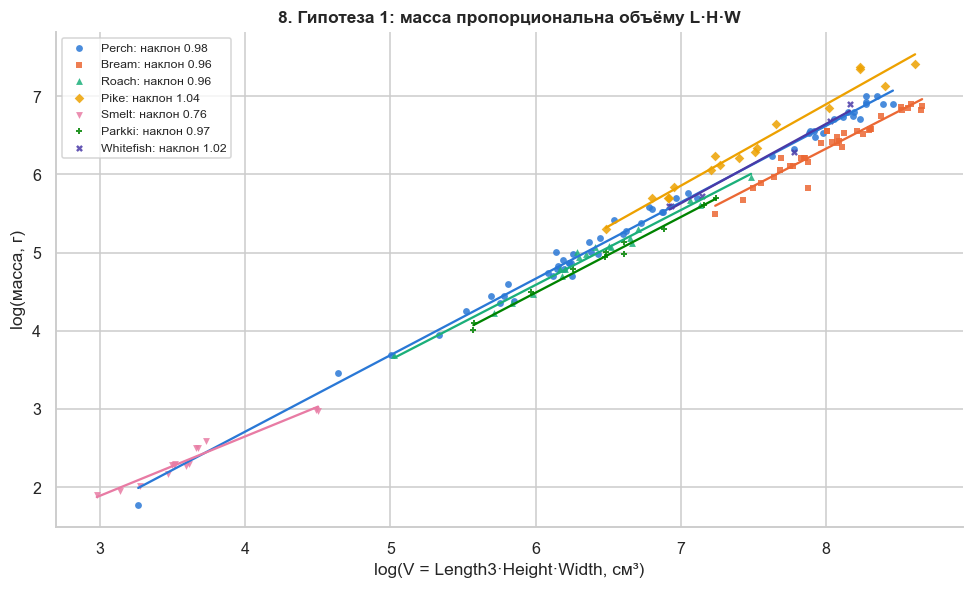

In [33]:
# ===== Ячейка 5.2 — график гипотезы 1 =====
fig, ax = plt.subplots(figsize=(9, 5.5))
for s in SPECIES_ORDER:
    part = df_h[df_h["Species"] == s]
    x, y = np.log(part["V"]), np.log(part["Weight"])
    b, a = np.polyfit(x, y, 1)
    ax.scatter(x, y, s=20, color=PALETTE[s], marker=MARKERS[s], alpha=0.85,
               linewidths=0, label=f"{s}: наклон {b:.2f}")
    xs = np.linspace(x.min(), x.max(), 10)
    ax.plot(xs, a + b * xs, color=PALETTE[s], lw=1.5)
ax.set(title="8. Гипотеза 1: масса пропорциональна объёму L·H·W",
       xlabel="log(V = Length3·Height·Width, см³)", ylabel="log(масса, г)")
ax.legend(fontsize=8)
fig.tight_layout(); save(fig, "08_volume_hypothesis"); plt.show()


In [34]:
# ===== Ячейка 5.3 — Гипотеза 2: форма тела (Height / Length3) различает виды =====
# Отдельная таблица, чтобы не добавлять столбцы в исходный df
shape = df[["Species", "Length3", "Height"]].copy()
shape["shape_h"] = (df["Height"] / df["Length3"] * 100).round(1)   # высота в % от длины
shape["shape_w"] = (df["Width"] / df["Length3"] * 100).round(1)    # ширина в % от длины

shape_stats = (shape.groupby("Species")["shape_h"]
                 .agg(["min", "median", "max", "count"])
                 .reindex(SPECIES_ORDER))
shape_stats

,min,median,max,count
Species,,,,
Perch,21.3,26.25,30.8,56
Bream,36.2,39.80,44.5,35
Roach,23.5,26.50,30.4,20
Pike,14.5,15.80,18.0,17
Smelt,14.9,16.85,18.9,14
Parkki,36.8,39.60,41.5,11
Whitefish,27.8,28.85,31.6,6


In [35]:
# ===== Ячейка 5.4 — насколько форма объясняет различия видов =====
def eta_squared(values, groups):
    """Доля разброса признака, объяснённая принадлежностью к группе (0..1)."""
    grand = values.mean()
    between = values.groupby(groups).apply(lambda v: len(v) * (v.mean() - grand) ** 2).sum()
    total = ((values - grand) ** 2).sum()
    return between / total

eta = pd.Series({
    "Height / Length3 (форма)": eta_squared(shape["shape_h"], shape["Species"]),
    "Width / Length3 (форма)":  eta_squared(shape["shape_w"], shape["Species"]),
    "Length3 (размер)":         eta_squared(shape["Length3"], shape["Species"]),
    "Height (размер)":          eta_squared(shape["Height"], shape["Species"]),
}, name="η² по виду").round(3)
eta

Height / Length3 (форма)    0.964
Width / Length3 (форма)     0.774
Length3 (размер)            0.629
Height (размер)             0.757
Name: η² по виду, dtype: float64

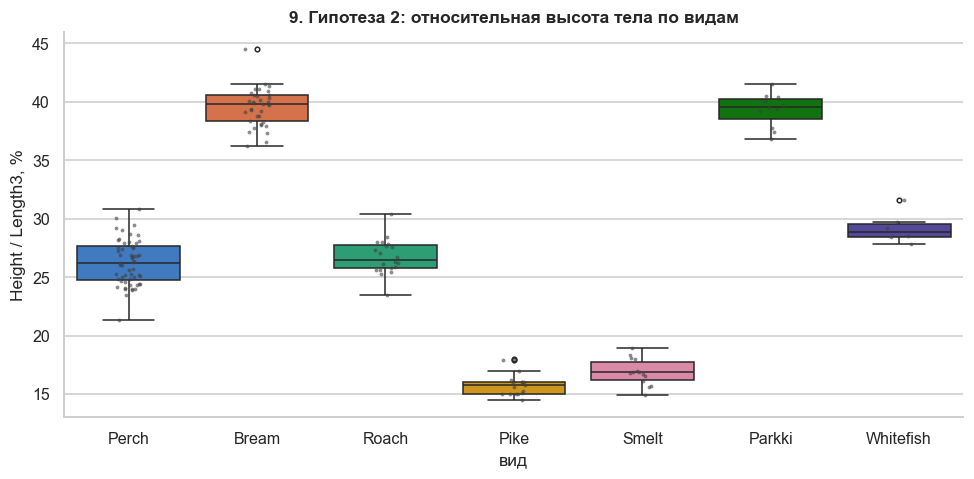

In [36]:
# ===== Ячейка 5.5 — график гипотезы 2 =====
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=shape, x="Species", y="shape_h", order=SPECIES_ORDER, hue="Species",
            palette=PALETTE, legend=False, ax=ax, fliersize=3)
sns.stripplot(data=shape, x="Species", y="shape_h", order=SPECIES_ORDER,
              color="0.25", size=2.5, alpha=0.6, ax=ax)
ax.set(title="9. Гипотеза 2: относительная высота тела по видам",
       xlabel="вид", ylabel="Height / Length3, %")
fig.tight_layout(); save(fig, "09_shape_by_species"); plt.show()


In [37]:
# ===== Ячейка 5.6 — мультиколлинеарность: корреляции и VIF =====
def vif(data):
    """VIF_j = 1 / (1 - R²_j), где R²_j — регрессия признака j на остальные."""
    out = {}
    X = data.to_numpy(dtype=float)
    for j, col in enumerate(data.columns):
        y = X[:, j]
        others = np.column_stack([np.ones(len(X)), np.delete(X, j, axis=1)])
        coef, *_ = np.linalg.lstsq(others, y, rcond=None)
        r2 = 1 - ((y - others @ coef) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        out[col] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(out).round(1)

display(df[["Length1", "Length2", "Length3"]].corr().round(4))
pd.DataFrame({
    "все 5 размеров": vif(df[["Length1", "Length2", "Length3", "Height", "Width"]]),
    "Length3, Height, Width": vif(df[["Length3", "Height", "Width"]]),
    "Length3 + форма": vif(shape[["Length3", "shape_h", "shape_w"]]),
})

,Length1,Length2,Length3
Length1,1.0000,0.9995,0.9920
Length2,0.9995,1.0000,0.9941
Length3,0.9920,0.9941,1.0000


,все 5 размеров,"Length3, Height, Width",Length3 + форма
Height,14.6,2.7,NaN
Length1,1681.5,NaN,NaN
Length2,2084.3,NaN,NaN
Length3,422.5,4.4,1.0
Width,12.3,6.0,NaN
shape_h,NaN,NaN,1.3
shape_w,NaN,NaN,1.3


In [38]:
# ===== Ячейка 5.7 — кодирование вида и новый вид =====
# One-hot: каждый вид — отдельный столбец 0/1. Список столбцов фиксируется
# по обучающей выборке; при появлении неизвестного вида все столбцы равны 0.
train_species = SPECIES_ORDER                      # виды, известные модели
new_fish = pd.Series(["Perch", "Carp"])            # Carp — вида нет в данных
encoded_new = pd.get_dummies(pd.Categorical(new_fish, categories=train_species))
encoded_new.index = new_fish
print("Неизвестный вид Carp → все столбцы 0; вид, которого нет в списке:",
      sorted(set(new_fish) - set(train_species)))
encoded_new.astype(int)

Неизвестный вид Carp → все столбцы 0; вид, которого нет в списке: ['Carp']


,Perch,Bream,Roach,Pike,Smelt,Parkki,Whitefish
Perch,1,0,0,0,0,0,0
Carp,0,0,0,0,0,0,0


## 6. Разбиение и утечки

In [39]:
# ===== Ячейка 6.1 — подготовка: что входит в разбиение =====
from src import splitting as sp

# Строка 40 (Weight = 0) — ошибка целевой переменной: в разбиение не входит.
df_model = df[df["Weight"] > 0].copy()

# Группы: каждая строка — своя группа, кроме пары 103/104
# (возможное повторное измерение одной рыбы, см. раздел 2).
df_model["group"] = df_model.index
df_model.loc[[103, 104], "group"] = 103

print("Строк для моделирования:", len(df_model), "| групп:", df_model["group"].nunique())

Строк для моделирования: 158 | групп: 157


In [40]:
# ===== Ячейка 6.2 — разбиение 70 / 15 / 15 =====
df_model["split"] = sp.stratified_group_split(
    df_model, strat_col="Species", group_col="group", seed=SEED)

sp.check_split(df_model["split"], df_model["group"])   # пересечений нет, группы целы
print("Проверки разбиения пройдены")

df_model["split"].value_counts().reindex(sp.SPLITS)

Проверки разбиения пройдены


train    110
val       24
test      24
Name: split, dtype: int64

In [41]:
# ===== Ячейка 6.2 — разбиение 70 / 15 / 15 =====
df_model["split"] = sp.stratified_group_split(
    df_model, strat_col="Species", group_col="group", seed=SEED)

sp.check_split(df_model["split"], df_model["group"])   # пересечений нет, группы целы
print("Проверки разбиения пройдены")

df_model["split"].value_counts().reindex(sp.SPLITS)

Проверки разбиения пройдены


train    110
val       24
test      24
Name: split, dtype: int64

In [42]:
# ===== Ячейка 6.4 — воспроизводимость: повтор с тем же seed =====
again = sp.stratified_group_split(df_model, "Species", "group", seed=SEED)
assert (again == df_model["split"]).all(), "разбиение не воспроизводится"
other = sp.stratified_group_split(df_model, "Species", "group", seed=SEED + 1)
print("Тот же seed → то же разбиение: да")
print("Другой seed → изменилось строк:", int((other != df_model["split"]).sum()))

Тот же seed → то же разбиение: да
Другой seed → изменилось строк: 80


In [43]:
# ===== Ячейка 6.5 — сохранение разбиения =====
SPLIT_PATH = Path("../data/split_lab01.csv")
SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_model[["Species", "group", "split"]].rename_axis("row").to_csv(SPLIT_PATH)
print("Сохранено:", SPLIT_PATH.resolve())

Сохранено: C:\Users\Max\Desktop\university_labs\AI_labs\lab1\ai_lab1\data\split_lab01.csv


## 7. Выводы
- Данные: 159 × 7, пропусков и дубликатов нет. Height и Width вычислены
  из % от Length3 (159/159). Первоисточник недоступен, лицензия не установлена.
- Аномалия: строка 40 (Weight = 0) — ошибка, исключена из разбиения.
  Выбросы по IQR/MAD (крупные особи) — не ошибки, оставлены.
- Масса ~ длина³ (масса ~ объём L·H·W), зависимость нелинейная →
  для модели использовать log(масса).
- Форма тела (Height/Length3) различает виды; вид — обязательный признак.
- Length1–3 дублируют друг друга (VIF до ~2000); «Length3 + форма» → VIF ≈ 1.
- Разбиение 70/15/15, стратификация по виду, пара 103/104 в одной группе,
  SEED = 42, сохранено в data/split_lab01.csv.
- Ограничения: Whitefish — 6 рыб (1 в тесте); независимость строк
  не проверяема; данные из одного исторического источника.